In [17]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
m=100

X_pos=np.random.randn(50,1)+2
X_neg=np.random.randn(50,1)-2
X=np.vstack([X_pos,X_neg])

y=np.vstack([np.ones((50,1)),np.zeros((50,1))])

X_b=np.c_[np.ones((m,1)),X]

print("X_b shape:",X_b.shape)
print("y shape:",y.shape)
print("前5个样本:\n",np.hstack([X_b[:5],y[:5]]))

X_b shape: (100, 2)
y shape: (100, 1)
前5个样本:
 [[1.         2.49671415 1.        ]
 [1.         1.8617357  1.        ]
 [1.         2.64768854 1.        ]
 [1.         3.52302986 1.        ]
 [1.         1.76584663 1.        ]]


In [16]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def compute_loss(X_b,y,w):
    z=X_b@w
    y_prob=sigmoid(z)

    loss=-np.mean(y*np.log(y_prob+1e-8)+(1-y)*np.log(1-y_prob+1e-8))
    return loss


In [15]:
lr = 0.1
epochs=1000
w=np.zeros((2,1))
loss_history=[]

for i in range(epochs):
    z=X_b@w
    y_prob=sigmoid(z)

    loss=compute_loss(X_b,y,w)
    loss_history.append(loss)

    gradient =(1/m)*X_b.T @(y_prob-y)

    w=w-lr*gradient

    if i%100==0:
        print(f"Epoch{i:4d}:loss={loss:.4f}")

print(f"\n最终参数:b={w[0][0]:.4f},w={w[1][0]:.4f}")

Epoch   0:loss=0.6931
Epoch 100:loss=0.0841
Epoch 200:loss=0.0591
Epoch 300:loss=0.0484
Epoch 400:loss=0.0421
Epoch 500:loss=0.0378
Epoch 600:loss=0.0346
Epoch 700:loss=0.0321
Epoch 800:loss=0.0301
Epoch 900:loss=0.0284

最终参数:b=0.5381,w=3.8026


Accuracy:100.00%


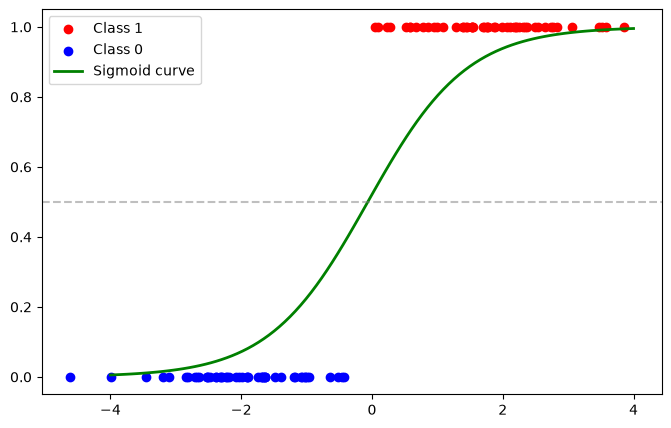

In [27]:
y_prob=sigmoid(X_b@w)
y_pred=(y_prob>=0.5).astype(int)

accuracy=np.mean(y_pred==y)
print(f"Accuracy:{accuracy:.2%}")

plt.figure(figsize=(8,5))
plt.scatter(X[:50],y[:50],color='red',label='Class 1')
plt.scatter(X[50:],y[50:],color='blue',label='Class 0')

x_range=np.linspace(-4,4,100).reshape(-1,1)
x_range_b=np.c_[np.ones((100,1)),x_range]
y_range_prob=sigmoid(x_range_b@w)
plt.plot(x_range,y_range_prob,color='green',linewidth=2,label='Sigmoid curve')
plt.axhline(y=0.5,color='gray',linestyle='--',alpha=0.5)
plt.legend()
plt.show()

In [26]:
###L2正则化
lambda_reg = 0.1 

for i in range(epochs):
    z = X_b@w
    y_prob=sigmoid(z)

    loss= -np.mean(y*np.log(y_prob+1e-8)+(1-y)*np.log(1-y_prob+1e-8))

    gradient =(1/m)*X_b.T@(y_prob-y)+lambda_reg*w

    w=w-lr*gradient

In [47]:
###K折交叉验证
from sklearn.metrics import f1_score
from sklearn.model_selection import KFold

kf = KFold(n_splits=5, shuffle=True, random_state=42)
f1_scores = []

# split必须传入 X_b 和 y！分层需要知道标签分布
for train_idx, val_idx in kf.split(X_b, y):
    X_train,X_val=X_b[train_idx],X_b[val_idx]
    y_train,y_val=y[train_idx],y[val_idx]
    w=np.zeros((X_train.shape[1],1))
    m=X_train.shape[0]
    loss_history=[]

    ###训练循环【重点！这个for要缩进，放在k折循环内部！】
    for i in range(epochs):
        z=X_train@w
        y_prob=sigmoid(z)
        loss=compute_loss(X_train,y_train,w)
        loss_history.append(loss)
        gradient =(1/m)*X_train.T @(y_prob-y_train)
        w=w-lr*gradient
    ###训练循环结束！退出epoch循环之后，再做验证集预测！

    # 预测评估，也在k折循环里面，但是在epochs循环外面！
    y_pred=(sigmoid(X_val@w)>=0.5).astype(int)
    f1= f1_score(y_val.ravel(),y_pred.ravel())
    f1_scores.append(f1)

print(f"5折F1:{f1_scores}")
print(f"平均F1:{np.mean(f1_scores):.4f}")


5折F1:[1.0, 1.0, 1.0, 1.0, 1.0]
平均F1:1.0000
